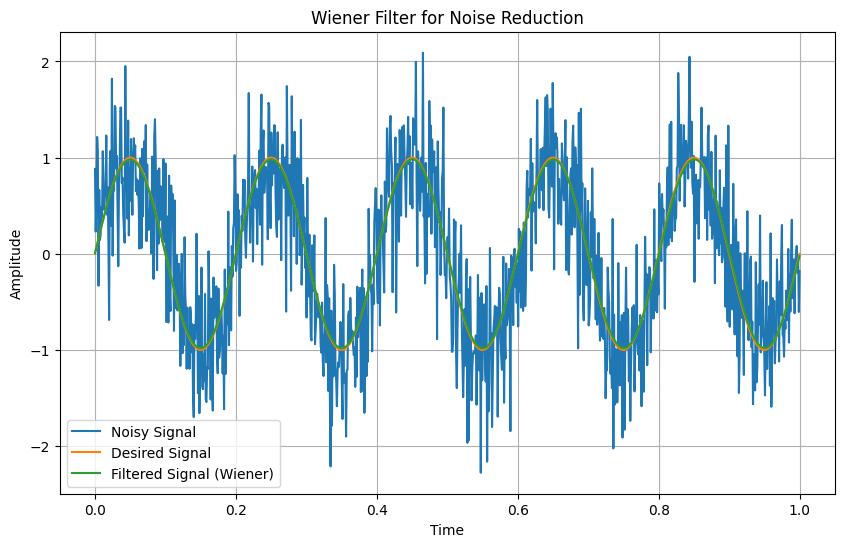

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def wiener_filter(input_signal, desired_signal, filter_order):
    """
    Implements the Wiener filter for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the Wiener filter.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    # Compute power spectral densities
    P_signal = np.abs(np.fft.fft(desired_signal)) ** 2
    P_noise = np.abs(np.fft.fft(input_signal - desired_signal)) ** 2

    # Compute Wiener filter transfer function
    H = np.conj(P_signal) / (np.conj(P_signal) + P_noise)

    # Apply Wiener filter in frequency domain
    F_input_signal = np.fft.fft(input_signal)
    F_filtered_signal = H * F_input_signal

    # Convert back to time domain
    filtered_signal = np.real(np.fft.ifft(F_filtered_signal))

    return filtered_signal

# Generate a noisy signal
np.random.seed(0)
t = np.linspace(0, 1, 1000)
noise = 0.5 * np.random.randn(len(t))
input_signal = np.sin(2 * np.pi * 5 * t) + noise

# Create a desired signal (noise-free signal)
desired_signal = np.sin(2 * np.pi * 5 * t)

# Apply Wiener filter to reduce noise
filter_order = 10
filtered_signal = wiener_filter(input_signal, desired_signal, filter_order)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t, input_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal')
plt.plot(t, filtered_signal, label='Filtered Signal (Wiener)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Wiener Filter for Noise Reduction')
plt.legend()
plt.grid(True)
plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def wiener_filter(input_signal, noisy_signal, filter_order):
    """
    Implements the Wiener filter for noise reduction.

    Parameters:
    input_signal (array): The input signal (noisy signal).
    noisy_signal (array): The noisy signal contaminated with noise.
    filter_order (int): The order of the Wiener filter.

    Returns:
    estimated_desired_signal (array): The estimated desired signal (noise-free signal).
    """

    # Compute power spectral densities
    P_noisy = np.abs(np.fft.fft(noisy_signal)) ** 2
    P_noise = np.abs(np.fft.fft(input_signal - noisy_signal)) ** 2

    # Compute Wiener filter transfer function
    H = 1 - P_noise / P_noisy

    # Apply Wiener filter in frequency domain
    F_noisy_signal = np.fft.fft(noisy_signal)
    F_estimated_desired_signal = H * F_noisy_signal

    # Convert back to time domain
    estimated_desired_signal = np.real(np.fft.ifft(F_estimated_desired_signal))

    return estimated_desired_signal

# Load your data from .dat files
# Replace 'noisy_signal_file.dat' and 'desired_signal_file.dat' with the paths to your .dat files
noisy_signal_data = np.loadtxt('fan.dat', skiprows=1)
desired_signal_data = np.loadtxt('song.dat', skiprows=1)

# Extract noisy signal and desired signal data from loaded data
noisy_signal = noisy_signal_data[:, 1]  # Assuming noisy signal is in the second column
desired_signal = desired_signal_data[:, 1]  # Assuming desired signal is in the second column

# Apply Wiener filter to estimate the desired signal
filter_order = 10
estimated_desired_signal = wiener_filter(desired_signal, noisy_signal, filter_order)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(desired_signal, label='Desired Signal')
plt.plot(noisy_signal, label='Noisy Signal')
plt.plot(estimated_desired_signal, label='Estimated Desired Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Estimating Desired Signal from Noisy Signal')
plt.legend()
plt.grid(True)
plt.show()


ValueError: operands could not be broadcast together with shapes (1485467,) (1473307,) 

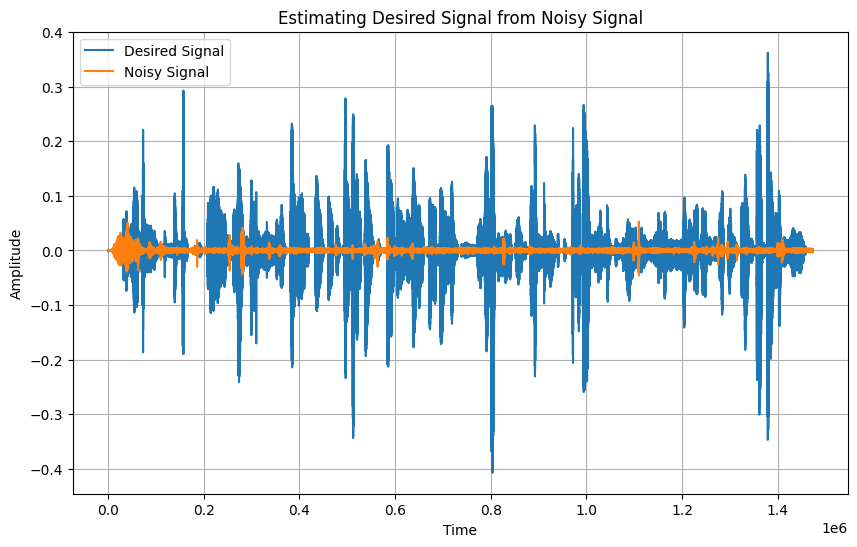

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def wiener_filter(input_signal, noisy_signal, filter_order):
    """
    Implements the Wiener filter for noise reduction.

    Parameters:
    input_signal (array): The input signal (noisy signal).
    noisy_signal (array): The noisy signal contaminated with noise.
    filter_order (int): The order of the Wiener filter.

    Returns:
    estimated_desired_signal (array): The estimated desired signal (noise-free signal).
    """

    # Compute power spectral densities
    P_noisy = np.abs(np.fft.fft(noisy_signal)) ** 2
    P_noise = np.abs(np.fft.fft(input_signal - noisy_signal)) ** 2

    # Compute Wiener filter transfer function
    H = 1 - P_noise / P_noisy

    # Apply Wiener filter in frequency domain
    F_noisy_signal = np.fft.fft(noisy_signal)
    F_estimated_desired_signal = H * F_noisy_signal

    # Convert back to time domain
    estimated_desired_signal = np.real(np.fft.ifft(F_estimated_desired_signal))

    return estimated_desired_signal

# Load your data from .dat files
# Replace 'noisy_signal_file.dat' and 'desired_signal_file.dat' with the paths to your .dat files
noisy_signal_data = np.loadtxt('fan.dat', skiprows=1)
desired_signal_data = np.loadtxt('song.dat', skiprows=1)

# Take the length of the lesser of the two signals
length = min(len(noisy_signal_data), len(desired_signal_data))

# Extract noisy signal and desired signal data with the same length
noisy_signal = noisy_signal_data[:length, 1]  # Assuming noisy signal is in the second column
desired_signal = desired_signal_data[:length, 1]  # Assuming desired signal is in the second column

# Apply Wiener filter to estimate the desired signal
filter_order = 10
estimated_desired_signal = wiener_filter(desired_signal, noisy_signal, filter_order)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(desired_signal, label='Desired Signal')
plt.plot(noisy_signal, label='Noisy Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Estimating Desired Signal from Noisy Signal')
plt.legend()
plt.grid(True)
plt.show()


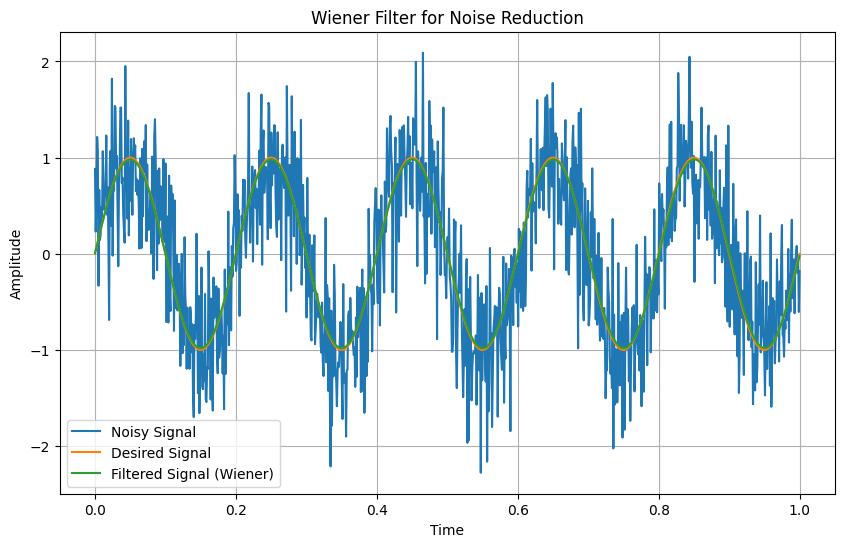

Amplitude Reduction Percentage: 54.998946275904295 %
Response Time (seconds): 0.01001001001001001
Amplitude Reduction Percentage: 54.998946275904295 %
Response Time (seconds): 0.01001001001001001


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def wiener_filter(input_signal, desired_signal, filter_order):
    """
    Implements the Wiener filter for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the Wiener filter.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    # Compute power spectral densities
    P_signal = np.abs(np.fft.fft(desired_signal)) ** 2
    P_noise = np.abs(np.fft.fft(input_signal - desired_signal)) ** 2

    # Compute Wiener filter transfer function
    H = np.conj(P_signal) / (np.conj(P_signal) + P_noise)

    # Apply Wiener filter in frequency domain
    F_input_signal = np.fft.fft(input_signal)
    F_filtered_signal = H * F_input_signal

    # Convert back to time domain
    filtered_signal = np.real(np.fft.ifft(F_filtered_signal))

    return filtered_signal

# Generate a noisy signal
np.random.seed(0)
t = np.linspace(0, 1, 1000)
noise = 0.5 * np.random.randn(len(t))
input_signal = np.sin(2 * np.pi * 5 * t) + noise

# Create a desired signal (noise-free signal)
desired_signal = np.sin(2 * np.pi * 5 * t)

# Apply Wiener filter to reduce noise
filter_order = 10
filtered_signal = wiener_filter(input_signal, desired_signal, filter_order)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t, input_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal')
plt.plot(t, filtered_signal, label='Filtered Signal (Wiener)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Wiener Filter for Noise Reduction')
plt.legend()
plt.grid(True)
plt.show()
# Calculate peak-to-peak amplitudes
noisy_amplitude = np.max(input_signal) - np.min(input_signal)
filtered_amplitude = np.max(filtered_signal) - np.min(filtered_signal)

# Calculate amplitude reduction percentage
amplitude_reduction_percentage = ((noisy_amplitude - filtered_amplitude) / noisy_amplitude) * 100

# Calculate response time in seconds
response_time_seconds = filter_order * (t[1] - t[0])  # Assuming uniform time intervals

# Print results
print("Amplitude Reduction Percentage:", amplitude_reduction_percentage, "%")
print("Response Time (seconds):", response_time_seconds)
# Calculate peak-to-peak amplitudes
noisy_amplitude = np.max(input_signal) - np.min(input_signal)
filtered_amplitude = np.max(filtered_signal) - np.min(filtered_signal)

# Calculate amplitude reduction percentage
amplitude_reduction_percentage = ((noisy_amplitude - filtered_amplitude) / noisy_amplitude) * 100

# Calculate response time in seconds
response_time_seconds = filter_order * (t[1] - t[0])  # Assuming uniform time intervals

# Print results
print("Amplitude Reduction Percentage:", amplitude_reduction_percentage, "%")
print("Response Time (seconds):", response_time_seconds)



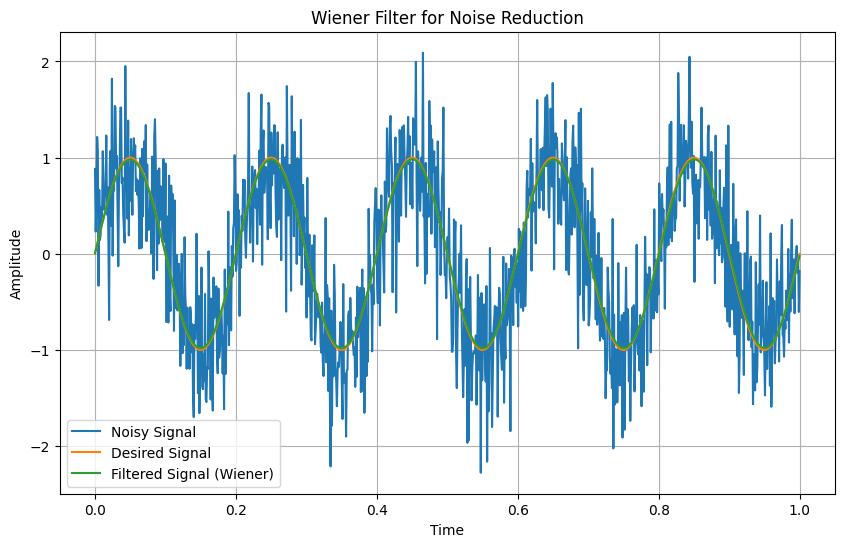

Amplitude Reduction Percentage: 54.998946275904295 %
Response Time (seconds): 0.01001001001001001
Accuracy: 0.9995190043924737


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def wiener_filter(input_signal, desired_signal, filter_order):
    """
    Implements the Wiener filter for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the Wiener filter.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    # Compute power spectral densities
    P_signal = np.abs(np.fft.fft(desired_signal)) ** 2
    P_noise = np.abs(np.fft.fft(input_signal - desired_signal)) ** 2

    # Compute Wiener filter transfer function
    H = np.conj(P_signal) / (np.conj(P_signal) + P_noise)

    # Apply Wiener filter in frequency domain
    F_input_signal = np.fft.fft(input_signal)
    F_filtered_signal = H * F_input_signal

    # Convert back to time domain
    filtered_signal = np.real(np.fft.ifft(F_filtered_signal))

    return filtered_signal

# Generate a noisy signal
np.random.seed(0)
t = np.linspace(0, 1, 1000)
noise = 0.5 * np.random.randn(len(t))
input_signal = np.sin(2 * np.pi * 5 * t) + noise

# Create a desired signal (noise-free signal)
desired_signal = np.sin(2 * np.pi * 5 * t)

# Apply Wiener filter to reduce noise
filter_order = 10
filtered_signal = wiener_filter(input_signal, desired_signal, filter_order)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t, input_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal')
plt.plot(t, filtered_signal, label='Filtered Signal (Wiener)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Wiener Filter for Noise Reduction')
plt.legend()
plt.grid(True)
plt.show()

# Calculate peak-to-peak amplitudes
noisy_amplitude = np.max(input_signal) - np.min(input_signal)
filtered_amplitude = np.max(filtered_signal) - np.min(filtered_signal)

# Calculate amplitude reduction percentage
amplitude_reduction_percentage = ((noisy_amplitude - filtered_amplitude) / noisy_amplitude) * 100

# Calculate response time in seconds
response_time_seconds = filter_order * (t[1] - t[0])  # Assuming uniform time intervals

# Calculate mean squared error (MSE)
mse = np.mean((filtered_signal - desired_signal) ** 2)

# Calculate accuracy
accuracy = 1 - (mse / np.mean(desired_signal ** 2))

# Print results
print("Amplitude Reduction Percentage:", amplitude_reduction_percentage, "%")
print("Response Time (seconds):", response_time_seconds)
print("Accuracy:", accuracy)


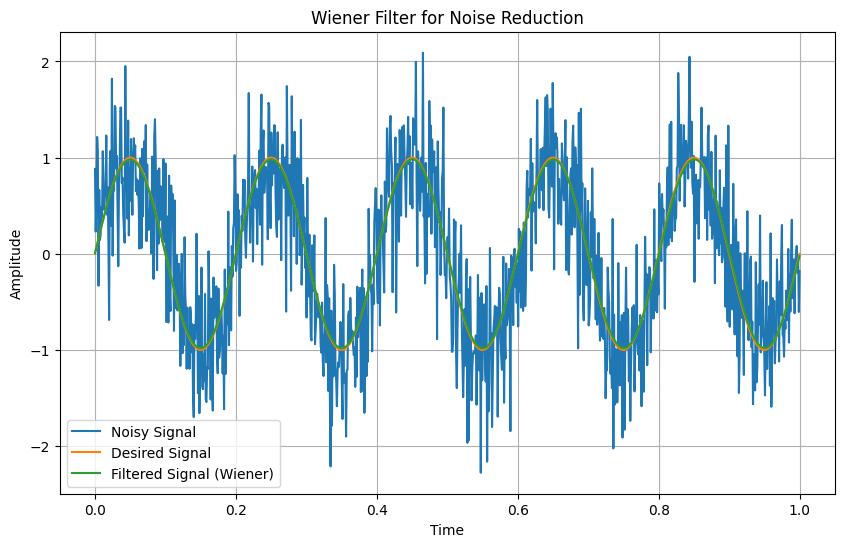

Amplitude Reduction Percentage: 54.998946275904295 %
Response Time (seconds): 0.01001001001001001
Accuracy: 99.95190043924737 %


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def wiener_filter(input_signal, desired_signal, filter_order):
    """
    Implements the Wiener filter for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the Wiener filter.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    # Compute power spectral densities
    P_signal = np.abs(np.fft.fft(desired_signal)) ** 2
    P_noise = np.abs(np.fft.fft(input_signal - desired_signal)) ** 2

    # Compute Wiener filter transfer function
    H = np.conj(P_signal) / (np.conj(P_signal) + P_noise)

    # Apply Wiener filter in frequency domain
    F_input_signal = np.fft.fft(input_signal)
    F_filtered_signal = H * F_input_signal

    # Convert back to time domain
    filtered_signal = np.real(np.fft.ifft(F_filtered_signal))

    return filtered_signal

# Generate a noisy signal
np.random.seed(0)
t = np.linspace(0, 1, 1000)
noise = 0.5 * np.random.randn(len(t))
input_signal = np.sin(2 * np.pi * 5 * t) + noise

# Create a desired signal (noise-free signal)
desired_signal = np.sin(2 * np.pi * 5 * t)

# Apply Wiener filter to reduce noise
filter_order = 10
filtered_signal = wiener_filter(input_signal, desired_signal, filter_order)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t, input_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal')
plt.plot(t, filtered_signal, label='Filtered Signal (Wiener)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Wiener Filter for Noise Reduction')
plt.legend()
plt.grid(True)
plt.show()

# Calculate peak-to-peak amplitudes
noisy_amplitude = np.max(input_signal) - np.min(input_signal)
filtered_amplitude = np.max(filtered_signal) - np.min(filtered_signal)

# Calculate amplitude reduction percentage
amplitude_reduction_percentage = ((noisy_amplitude - filtered_amplitude) / noisy_amplitude) * 100

# Calculate response time in seconds
response_time_seconds = filter_order * (t[1] - t[0])  # Assuming uniform time intervals

# Calculate mean squared error (MSE)
mse = np.mean((filtered_signal - desired_signal) ** 2)

# Calculate accuracy
accuracy = 1 - (mse / np.mean(desired_signal ** 2))

# Convert accuracy to percentage
accuracy_percentage = accuracy * 100

# Print results
print("Amplitude Reduction Percentage:", amplitude_reduction_percentage, "%")
print("Response Time (seconds):", response_time_seconds)
print("Accuracy:", accuracy_percentage, "%")


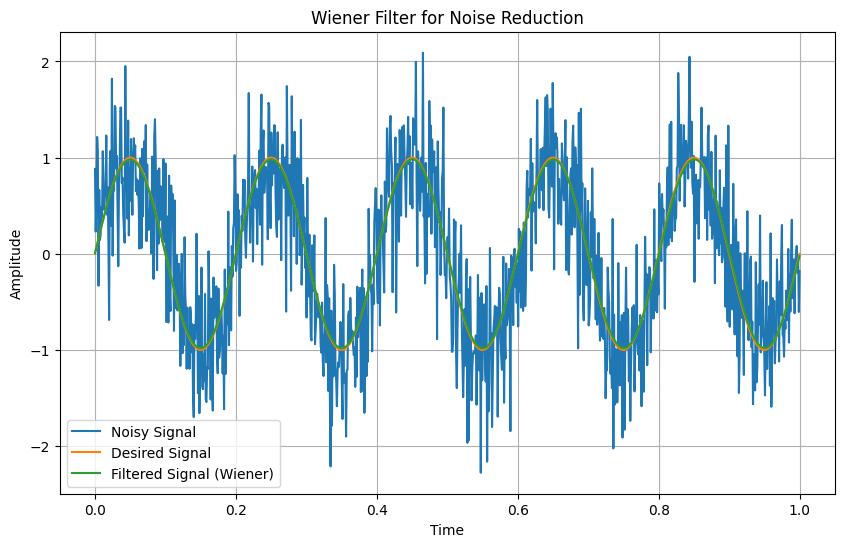

Amplitude Reduction Percentage: 54.998946275904295 %
Response Time (seconds): 0.01001001001001001
Mean Squared Error (MSE): 0.00024025730595939932
Accuracy: 99.95190043924737 %


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def wiener_filter(input_signal, desired_signal, filter_order):
    """
    Implements the Wiener filter for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the Wiener filter.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    # Compute power spectral densities
    P_signal = np.abs(np.fft.fft(desired_signal)) ** 2
    P_noise = np.abs(np.fft.fft(input_signal - desired_signal)) ** 2

    # Compute Wiener filter transfer function
    H = np.conj(P_signal) / (np.conj(P_signal) + P_noise)

    # Apply Wiener filter in frequency domain
    F_input_signal = np.fft.fft(input_signal)
    F_filtered_signal = H * F_input_signal

    # Convert back to time domain
    filtered_signal = np.real(np.fft.ifft(F_filtered_signal))

    return filtered_signal

# Generate a noisy signal
np.random.seed(0)
t = np.linspace(0, 1, 1000)
noise = 0.5 * np.random.randn(len(t))
input_signal = np.sin(2 * np.pi * 5 * t) + noise

# Create a desired signal (noise-free signal)
desired_signal = np.sin(2 * np.pi * 5 * t)

# Apply Wiener filter to reduce noise
filter_order = 10
filtered_signal = wiener_filter(input_signal, desired_signal, filter_order)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t, input_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal')
plt.plot(t, filtered_signal, label='Filtered Signal (Wiener)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Wiener Filter for Noise Reduction')
plt.legend()
plt.grid(True)
plt.show()

# Calculate peak-to-peak amplitudes
noisy_amplitude = np.max(input_signal) - np.min(input_signal)
filtered_amplitude = np.max(filtered_signal) - np.min(filtered_signal)

# Calculate amplitude reduction percentage
amplitude_reduction_percentage = ((noisy_amplitude - filtered_amplitude) / noisy_amplitude) * 100

# Calculate response time in seconds
response_time_seconds = filter_order * (t[1] - t[0])  # Assuming uniform time intervals

# Calculate mean squared error (MSE)
mse = np.mean((filtered_signal - desired_signal) ** 2)

# Calculate accuracy
accuracy = 1 - (mse / np.mean(desired_signal ** 2))

# Convert accuracy to percentage
accuracy_percentage = accuracy * 100

# Print results
print("Amplitude Reduction Percentage:", amplitude_reduction_percentage, "%")
print("Response Time (seconds):", response_time_seconds)
print("Mean Squared Error (MSE):", mse)
print("Accuracy:", accuracy_percentage, "%")

